In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
colors = sns.color_palette().as_hex()
ambiente_pallete = {
    'Notebook': colors[0],
    'Servidor': colors[1]
}
tipo_pallete = {
    'Seq': colors[4],
    'Rand': colors[3]
}

df_notebook = pd.read_csv('../data/btree_notebook_sem_reuso.csv')
df_servidor = pd.read_csv('../data/btree_servidor_sem_reuso.csv')

df_notebook['Ambiente'] = 'Notebook'
df_servidor['Ambiente'] = 'Servidor'

df_total = pd.concat([df_notebook, df_servidor], ignore_index=True)
df_base = df_notebook.copy()

## PARTE 1: Validação Teórica da Árvore B
O objetivo primário da implementação da Árvore B é a redução de operações de I/O em memória secundária. Essa seção comprova matematicamente o comportamento da estrutura perante a variação da ordem (M), independentemente do hardware utilizado.

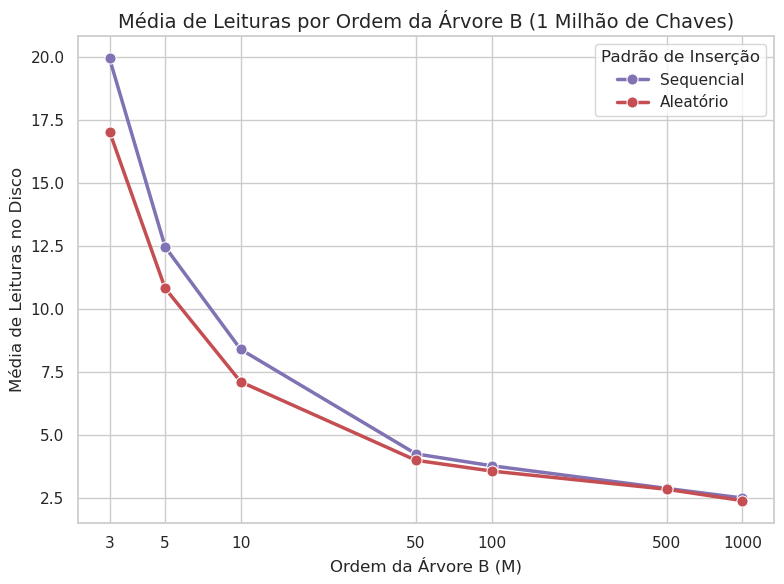

In [86]:
df_teoria_1m = df_base[df_base['numKeys'] == 1000000].copy()

plt.figure(figsize=(8, 6))

sns.lineplot(data=df_teoria_1m, x='M', y='avg_reads', hue='tipo', 
             marker='o', linewidth=2.5, markersize=8, palette=tipo_pallete)

plt.title('Média de Leituras por Ordem da Árvore B (1 Milhão de Chaves)', fontsize=14)
plt.xlabel('Ordem da Árvore B (M)', fontsize=12)
plt.ylabel('Média de Leituras no Disco', fontsize=12)

plt.xscale('log')
plt.xticks(df_teoria_1m['M'].unique(), df_teoria_1m['M'].unique())
leg = plt.legend(title='Padrão de Inserção')
leg.get_texts()[0].set_text('Sequencial')
leg.get_texts()[1].set_text('Aleatório')

plt.tight_layout()
plt.show()

Este gráfico comprova o modelo teórico da disciplina. Com uma ordem pequena (M=3), a altura da árvore obriga a dezenas de leituras por chave. Ao aumentarmos M, a altura cai logaritmicamente, achatando a árvore e reduzindo os acessos ao disco para apenas 2 a 3 leituras, estabilizando a partir de M=100.

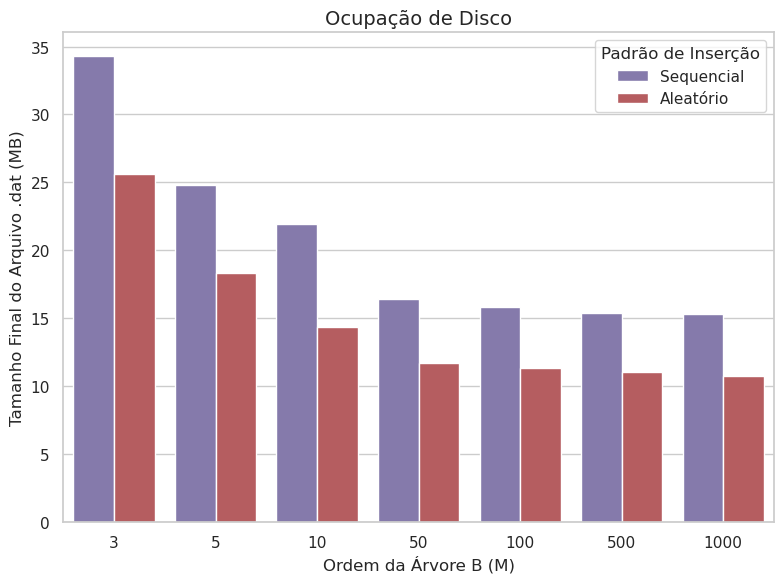

In [110]:
plt.figure(figsize=(8, 6))

df_teoria_1m['Tamanho (MB)'] = df_teoria_1m['bytes'] / (1024 * 1024)

sns.barplot(data=df_teoria_1m, x='M', y='Tamanho (MB)', hue='tipo', 
            palette=tipo_pallete)

plt.title('Ocupação de Disco', fontsize=14)
plt.xlabel('Ordem da Árvore B (M)', fontsize=12)
plt.ylabel('Tamanho Final do Arquivo .dat (MB)', fontsize=12)
leg = plt.legend(title='Padrão de Inserção')
leg.get_texts()[0].set_text('Sequencial')
leg.get_texts()[1].set_text('Aleatório')

plt.tight_layout()
plt.show()

Aqui provamos a matemática do preenchimento dos nós. A inserção puramente sequencial gera partições apenas à direita, deixando nós internos subutilizados. A inserção aleatória distribui as chaves e aproveita melhor os blocos, gerando um arquivo final menor.

## PARTE 2: Análise de Desempenho e Gargalos de Hardware
Apesar do número lógico de leituras ao disco ser igual em qualquer máquina, o *tempo* que essas operações demoram varia consoante a arquitetura mecânica e de processamento. Avaliamos a estrutura em dois cenários:
1. **HDD Local (Notebook):** Limitação mecânica de 5400 RPM da agulha.
2. **HDD em RAID (Servidor):** Sobrecarga na controladora de armazenamento ao lidar com ficheiros fragmentados.

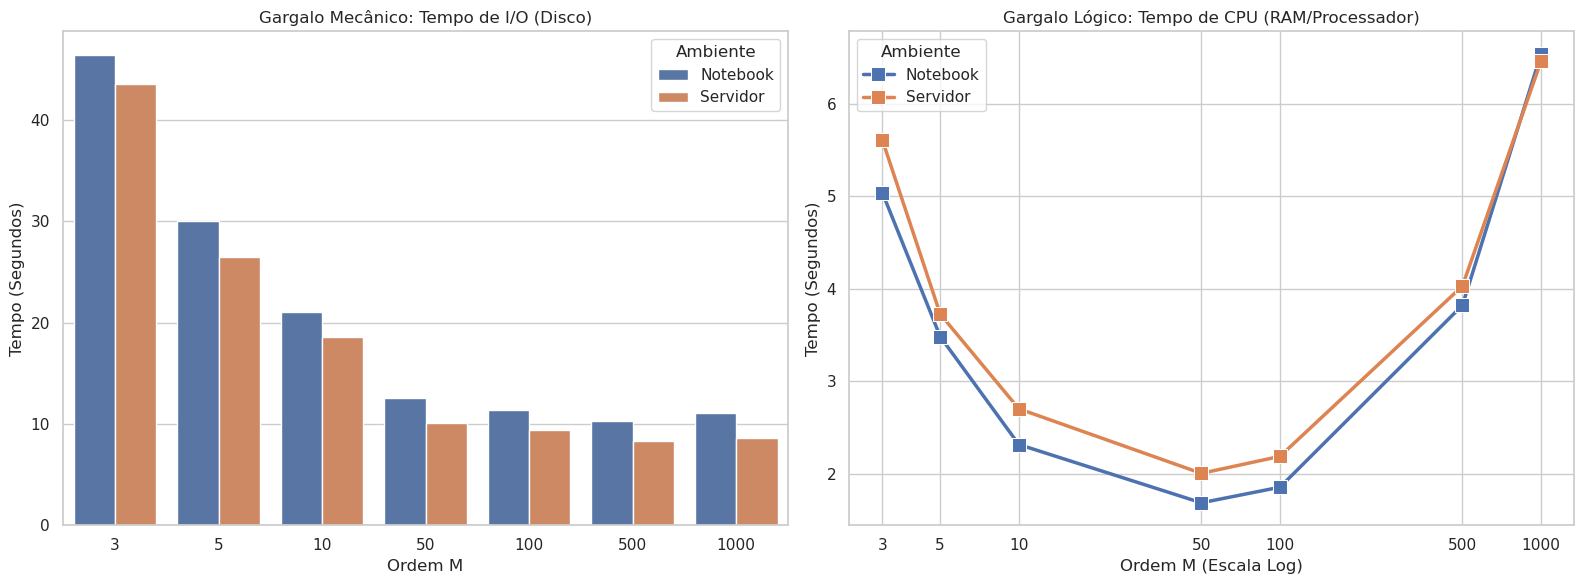

In [ ]:
df_hw_1m = df_total[(df_total['numKeys'] == 1000000) & (df_total['tipo'] == 'Seq')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], data=df_hw_1m, x='M', y='tempo_io', hue='Ambiente', palette=ambiente_pallete)
axes[0].set_title('Gargalo Mecânico: Tempo de I/O (Disco)')
axes[0].set_xlabel('Ordem M')
axes[0].set_ylabel('Tempo (Segundos)')

sns.lineplot(ax=axes[1], data=df_hw_1m, x='M', y='tempo_cpu', hue='Ambiente', marker='s', markersize=10, linewidth=2.5, palette=ambiente_pallete)
axes[1].set_title('Gargalo Lógico: Tempo de CPU (RAM/Processador)')
axes[1].set_xlabel('Ordem M')
axes[1].set_ylabel('Tempo (Segundos)')
axes[1].set_xscale('log')
axes[1].set_xticks(df_hw_1m['M'].unique())
axes[1].set_xticklabels(df_hw_1m['M'].unique())

plt.tight_layout()
plt.show()

No gráfico da esquerda, vemos como ordens pequenas destroem o desempenho de discos mecânicos. O arranjo RAID do Servidor (laranja) sofreu brutalmente com latência nas ordens m=3 e m=5. No gráfico da direita, o gargalo inverte: quando a ordem atinge m=1000, o disco descansa, mas os nossos processadores afogam-se para procurar chaves nos arrays gigantes da memória.

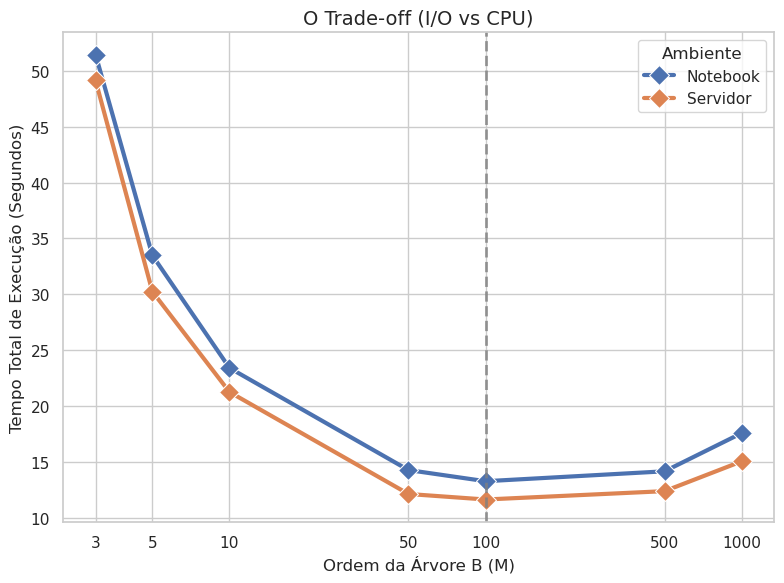

In [109]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=df_hw_1m, x='M', y='tempo_total', hue='Ambiente', 
             marker='D', markersize=10, linewidth=3, palette=ambiente_pallete)

plt.title('O Trade-off (I/O vs CPU)', fontsize=14)
plt.xlabel('Ordem da Árvore B (M)', fontsize=12)
plt.ylabel('Tempo Total de Execução (Segundos)', fontsize=12)
plt.xscale('log')
plt.xticks(df_hw_1m['M'].unique(), df_hw_1m['M'].unique())
plt.axvline(x=100, color='gray', linestyle='--', alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

Este gráfico de tempo total revela o 'Trade-off' clássico de Banco de Dados. À esquerda, sofremos com a latência mecânica do disco (I/O). À direita, sofremos com o limite de processamento de busca na memória (CPU). A linha vertical em M=100 prova que, independentemente se estamos num Notebook ou num Servidor, a ordem 100 foi o ponto de arquitetura perfeito que balanceou o peso entre o Disco e a CPU para a nossa implementação.